# ECB Scraping
Author: Natalia Namyslowska  
---

## 1. Introduction

The goal of this project is to scrape the European Central Bank (ECB) website and analyse how their communication about artificial intelligence, digital finance, and monetary policy has changed over the years 1997-2026.

I chose the ECB because my bachelor thesis was about sentiment analysis on Financial Times headlines, and I wanted to extend that idea to look at how a major institution like the ECB talks about topics like AI and digital currencies. 

I scraped two types of ECB documents:
- **Speeches** - talks given by ECB board members at conferences, universities, etc.
- **Press releases** - official announcements about policy decisions, appointments, etc.

The project uses all four required libraries:
- `requests` and `BeautifulSoup` - for downloading and parsing data
- `Selenium` - for extracting full speech text (browser automation)
- `Scrapy` - for extracting full press release text (crawling framework)
- `re` (regex) - for finding keyword mentions in the text

## 2. Why the ECB website is legal to scrape

Before starting the project I checked whether it is legal to scrape the ECB website. Here is what I found:

1. **EU Open Data Directive (2019/1024/EU)** - EU institutions are required to make their data reusable by the public. The ECB is an EU institution.

2. **ECB robots.txt** - I checked `https://www.ecb.europa.eu/robots.txt` and it does not have a general ban on scraping. It only blocks a few internal paths (like video files). It does specify `Crawl-delay: 5` which means we should wait 5 seconds between requests, and I respected that in all my scripts.

3. **ECB RSS feeds** - The ECB provides RSS feeds at `https://www.ecb.europa.eu/home/html/rss.en.html` which are designed for machines to read. If they provide machine-readable feeds, they clearly expect automated access.

4. **Non-commercial academic use** - This is a university project, not a commercial product. I am not selling the data or using it for profit.

5. **No personal data** - I am only scraping public speeches and press releases. No user data.

All of this is documented in the `legal_proof.txt` file included in the submission.

## 3. How I discovered the ECB data source

### First attempt: RSS feeds

My first idea was to use the ECB's RSS feeds because they are plain XML and `requests` can download them easily. The problem is that each RSS feed only returns the 15 most recent items. That gives me about 75 articles total across 5 feeds, which is way too little for a proper analysis of 1997-2026.

### Second attempt: archive pages

I tried to access year-based archive pages like `/press/key/date/2024/html/index.en.html` but those returned 404 errors. The ECB restructured their website at some point and the old URL pattern does not work anymore.

I did find that the `index_include.en.html` pages work (these are HTML fragments that the website's JavaScript loads), but they only cover certain content types and some years are missing.

### Final solution: the JSON dataset

By inspecting the network requests in the browser (using Chrome DevTools, Network tab), I discovered that the ECB's "All news & publications" page loads its data from a JSON API. The URL looks like this:

```
https://www.ecb.europa.eu/foedb/dbs/foedb/publications.en/.../metadata.json
```

This JSON dataset contains all ECB publications, thousands of records with metadata like title, date, type, and links. The data is split into chunks that can be downloaded with simple `requests.get()` calls.

There is also a separate `publications_types` dataset that maps type IDs to names. I wrote a small script (`discover_types.py`) to find that:
- **Type 1** = ECB Press release
- **Type 19** = ECB Speech


## 4. Project structure

Here is how the project is organised:

| File | What it does | Libraries used |
|------|-------------|----------------|
| `01_requests_json.py` | Collects speech and press release metadata from ECB JSON | `requests` |
| `02_selenium.py` | Extracts full speech text from HTML pages | `Selenium`, `BeautifulSoup` |
| `ecb_scrapy/` (Scrapy project) | Extracts full press release text | `Scrapy` |
| `04_analysis.ipynb` | Regex analysis and final dataframe | `re`, `pandas`, `matplotlib` |

I decided to use Selenium for speeches and Scrapy for press releases so that each tool handles a different content type.

Why not just use one tool for everything? I could have used just Selenium or just Scrapy for all the full-text extraction, but the course requires demonstrating all four libraries. By splitting the work between Selenium and Scrapy, each tool gets a real usage.

This short example below shows how `requests` and `BeautifulSoup` can fetch and parse a single ECB speech page directly from HTML. The method works correctly for one page, but it would be inefficient for the full archive because each page would need to be downloaded separately and the ECB robots.txt specifies a 5-second crawl delay between requests. For this reason, the project uses the ECB JSON dataset for metadata collection and reserves page-by-page scraping for the later full-text extraction steps.

In [25]:
import requests
import time
from bs4 import BeautifulSoup

url = "https://www.ecb.europa.eu/press/key/date/2011/html/sp110602.en.html"
total_pages = 2705 + 2184

start = time.time()
response = requests.get(url, timeout=30)
elapsed = time.time() - start

soup = BeautifulSoup(response.content, "html.parser")

title_tag = soup.find("title")
title = title_tag.get_text(strip=True) if title_tag else ""

text = ""
for selector in ["article", "main", "div.section"]:
    tags = soup.select(selector)
    parts = []

    for tag in tags:
        value = tag.get_text(" ", strip=True)
        if value:
            parts.append(value)

    combined_text = " ".join(parts).strip()

    if len(combined_text) >= 500:
        text = combined_text
        break

estimated_minutes = (total_pages * 5) / 60

print(f"Page title: {title}")
print(f"Extracted text length: {len(text)} characters")
print(f"Time for this single request: {elapsed:.2f} seconds")
print(f"Estimated waiting time for {total_pages} pages at 5-second delay: {estimated_minutes:.1f} minutes")

Page title: Building Europe, building institutions
Extracted text length: 21048 characters
Time for this single request: 0.12 seconds
Estimated waiting time for 4889 pages at 5-second delay: 407.4 minutes


## 5. Step 1 - Collecting article metadata with `requests`

The first step is to download the ECB's JSON dataset and extract metadata for speeches and press releases. This is handled in a script (`01_requests_json.py`), and the same logic is reproduced here in the notebook.

### How the JSON dataset works

1. First we download `metadata.json` which tells us how many records exist, what the fields are called, and how big each chunk is.
2. Then we download the data chunks (big JSON arrays with all the records).
3. We rebuild the rows by mapping each value to its field name using the header.
4. We filter by type (19 for speeches, 1 for press releases) and year (1997-2026).
5. We save to CSV.

### 5.1 Downloading metadata and data chunks

This cell downloads the ECB JSON dataset and rebuilds all rows. The same data is then used for both speech and press release filtering below.

In [ ]:
import requests
import csv
import os
import math
from datetime import datetime, UTC
from collections import Counter

BASE_DATASET = "https://www.ecb.europa.eu/foedb/dbs/foedb/publications.en/1775134838/wr3YWp5G"
METADATA_URL = BASE_DATASET + "/metadata.json"

OUTPUT_FILE_SPEECHES = "data/ecb_speeches_json.csv"
OUTPUT_FILE_PRESS = "data/ecb_press_releases_json.csv"

SPEECH_TYPE_ID = 19
PRESS_RELEASE_TYPE_ID = 1

START_YEAR = 1997
END_YEAR = 2026

os.makedirs("data", exist_ok=True)


# Helper functions:

def unix_to_date_string(timestamp_value):
    """Convert Unix timestamp to YYYY-MM-DD."""
    if timestamp_value is None:
        return ""
    try:
        timestamp_value = int(timestamp_value)
        return datetime.fromtimestamp(timestamp_value, UTC).strftime("%Y-%m-%d")
    except Exception:
        return ""


def get_best_link(document_types):
    """Return the best link: English HTML > English PDF > any PDF."""
    if not document_types:
        return ""
    for item in document_types:
        if isinstance(item, str) and item.endswith(".en.html"):
            return "https://www.ecb.europa.eu" + item if item.startswith("/") else item
    for item in document_types:
        if isinstance(item, str) and item.endswith(".en.pdf"):
            return "https://www.ecb.europa.eu" + item if item.startswith("/") else item
    for item in document_types:
        if isinstance(item, str) and item.endswith(".pdf"):
            return "https://www.ecb.europa.eu" + item if item.startswith("/") else item
    return ""


def get_title(properties):
    """Extract title from publicationProperties."""
    if not isinstance(properties, dict):
        return ""
    value = properties.get("Title", "")
    if isinstance(value, list):
        return value[0] if value else ""
    return value


def get_subtitle(properties):
    """Extract subtitle from publicationProperties."""
    if not isinstance(properties, dict):
        return ""
    value = properties.get("Subtitle", "")
    if isinstance(value, list):
        return value[0] if value else ""
    return value


def get_link_type(link):
    """Label the link as HTML or PDF."""
    if link.endswith(".html"):
        return "html"
    if link.endswith(".pdf"):
        return "pdf"
    return ""


def filter_rows(all_rows, target_type, doc_type_name, include_extra_fields=False):
    """Filter all rows for one publication type and keep useful fields."""
    filtered_rows = []
    for row in all_rows:
        if row.get("type") != target_type:
            continue
        row_year = row.get("year")
        if row_year is None:
            continue
        try:
            row_year = int(row_year)
        except Exception:
            continue
        if row_year < START_YEAR or row_year > END_YEAR:
            continue

        properties = row.get("publicationProperties", {})
        document_types = row.get("documentTypes", [])
        link = get_best_link(document_types)

        row_dict = {
            "doc_type": doc_type_name,
            "title": get_title(properties),
            "subtitle": get_subtitle(properties),
            "date": unix_to_date_string(row.get("pub_timestamp")),
            "year": row_year,
            "link": link,
            "link_type": get_link_type(link),
            "source": "json_dataset"
        }

        if include_extra_fields:
            row_dict["author"] = row.get("Authors", "")
            row_dict["boardmember"] = row.get("boardmember", "")
            row_dict["taxonomy"] = row.get("Taxonomy", "")

        filtered_rows.append(row_dict)
    return filtered_rows


def deduplicate_rows(rows):
    """Remove duplicates based on link."""
    unique_rows = []
    seen_links = set()
    for row in rows:
        link = row["link"]
        if not link or link in seen_links:
            continue
        seen_links.add(link)
        unique_rows.append(row)
    unique_rows.sort(key=lambda x: (x["year"], x["date"], x["title"]))
    return unique_rows


def save_csv(rows, output_file, fieldnames):
    """Save rows to CSV."""
    with open(output_file, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


# Downloading metadata and reading dataset structure:
meta_response = requests.get(METADATA_URL, timeout=30)
metadata = meta_response.json()

header = metadata["header"]
total_records = metadata["total_records"]
chunk_size = metadata["chunk_size"]
num_chunks = math.ceil(total_records / chunk_size)

print(f"Total records in dataset: {total_records}")
print(f"Chunks to download: {num_chunks}")


# Downloading chunks and rebuilding rows:

all_rows = []

for chunk_number in range(num_chunks):
    chunk_url = f"{BASE_DATASET}/data/0/chunk_{chunk_number}.json"
    response = requests.get(chunk_url, timeout=60)

    if response.status_code != 200:
        continue

    chunk_data = response.json()
    field_count = len(header)

    if len(chunk_data) % field_count != 0:
        continue

    rows_in_chunk = len(chunk_data) // field_count
    print(f"  Chunk {chunk_number + 1}/{num_chunks}: {rows_in_chunk} rows")

    for row_number in range(rows_in_chunk):
        start = row_number * field_count
        row_values = chunk_data[start:start + field_count]
        row_dict = dict(zip(header, row_values))
        all_rows.append(row_dict)

print(f"\nTotal rows: {len(all_rows)}")

Total records in dataset: 19667
Chunks to download: 79
  Chunk 1/79: 250 rows
  Chunk 2/79: 250 rows
  Chunk 3/79: 250 rows
  Chunk 4/79: 250 rows
  Chunk 5/79: 250 rows
  Chunk 6/79: 250 rows
  Chunk 7/79: 250 rows
  Chunk 8/79: 250 rows
  Chunk 9/79: 250 rows
  Chunk 10/79: 250 rows
  Chunk 11/79: 250 rows
  Chunk 12/79: 250 rows
  Chunk 13/79: 250 rows
  Chunk 14/79: 250 rows
  Chunk 15/79: 250 rows
  Chunk 16/79: 250 rows
  Chunk 17/79: 250 rows
  Chunk 18/79: 250 rows
  Chunk 19/79: 250 rows
  Chunk 20/79: 250 rows
  Chunk 21/79: 250 rows
  Chunk 22/79: 250 rows
  Chunk 23/79: 250 rows
  Chunk 24/79: 250 rows
  Chunk 25/79: 250 rows
  Chunk 26/79: 250 rows
  Chunk 27/79: 250 rows
  Chunk 28/79: 250 rows
  Chunk 29/79: 250 rows
  Chunk 30/79: 250 rows
  Chunk 31/79: 250 rows
  Chunk 32/79: 250 rows
  Chunk 33/79: 250 rows
  Chunk 34/79: 250 rows
  Chunk 35/79: 250 rows
  Chunk 36/79: 250 rows
  Chunk 37/79: 250 rows
  Chunk 38/79: 250 rows
  Chunk 39/79: 250 rows
  Chunk 40/79: 250

### 5.2 Filtering and saving speeches (type = 19)

In [ ]:
# Filtering for speeches:

speech_rows = filter_rows(
    all_rows=all_rows,
    target_type=SPEECH_TYPE_ID,
    doc_type_name="speech",
    include_extra_fields=True
)

unique_speeches = deduplicate_rows(speech_rows)

save_csv(
    rows=unique_speeches,
    output_file=OUTPUT_FILE_SPEECHES,
    fieldnames=[
        "doc_type", "title", "subtitle", "date", "year",
        "author", "boardmember", "taxonomy",
        "link", "link_type", "source"
    ]
)

print(f"Saved {len(unique_speeches)} speeches to {OUTPUT_FILE_SPEECHES}")

year_counts = Counter(r["year"] for r in unique_speeches)
for year in sorted(year_counts):
    print(f" {year}: {year_counts[year]}")

Saved 2855 speeches to data/ecb_speeches_json.csv
  1997: 19
  1998: 39
  1999: 94
  2000: 70
  2001: 68
  2002: 66
  2003: 65
  2004: 91
  2005: 81
  2006: 96
  2007: 118
  2008: 132
  2009: 112
  2010: 118
  2011: 119
  2012: 91
  2013: 133
  2014: 104
  2015: 104
  2016: 109
  2017: 148
  2018: 116
  2019: 112
  2020: 95
  2021: 100
  2022: 99
  2023: 104
  2024: 109
  2025: 113
  2026: 30


### 5.3 Filtering and saving press releases (type = 1)

The same `all_rows` data from above is reused.

In [70]:
# Filtering for press releases:

press_rows = filter_rows(
    all_rows=all_rows,
    target_type=PRESS_RELEASE_TYPE_ID,
    doc_type_name="press_release",
    include_extra_fields=False
)

unique_press = deduplicate_rows(press_rows)

save_csv(
    rows=unique_press,
    output_file=OUTPUT_FILE_PRESS,
    fieldnames=[
        "doc_type", "title", "subtitle", "date", "year",
        "link", "link_type", "source"
    ]
)

print(f"Saved {len(unique_press)} press releases to {OUTPUT_FILE_PRESS}")

year_counts_p = Counter(r["year"] for r in unique_press)
for year in sorted(year_counts_p):
    print(f"  {year}: {year_counts_p[year]}")

Saved 2186 press releases to data/ecb_press_releases_json.csv
  1997: 19
  1998: 48
  1999: 49
  2000: 42
  2001: 58
  2002: 67
  2003: 78
  2004: 81
  2005: 74
  2006: 69
  2007: 91
  2008: 105
  2009: 73
  2010: 91
  2011: 95
  2012: 90
  2013: 114
  2014: 115
  2015: 89
  2016: 67
  2017: 63
  2018: 64
  2019: 69
  2020: 93
  2021: 61
  2022: 65
  2023: 73
  2024: 67
  2025: 84
  2026: 32


## 6. Step 2 - Extracting full speech text with selenium

The JSON dataset gives us metadata (title, date, link) but not the full text of the speeches. To do keyword analysis we need the actual content. So I used Selenium to open each speech page and extract the text.

### Why Selenium and not just requests?

In theory, most ECB speech pages are static HTML so `requests` could work. Selenium demonstrates browser automation, additionally some ECB pages do load content with JavaScript, so Selenium is the safer option. I also included a fall back with BeautifulSoup if Selenium selectors fail and I saved the progress every 10 articles.

During testing I noticed that some pages would return only about 124 characters, which is just the page header/navigation text, not the actual speech content. I fixed this by setting a minimum threshold of 500 characters as a real speech is always thousands of characters long.

This step was run separately because it takes about 80 minutes for 615 speeches (5 second delay per page). The output file is `data/ecb_speeches_full_text.csv`.

The Selenium script (`02_selenium.py`) was run separately before this notebook. The results are loaded in the analysis section below.

## 7. Step 3 - Extracting full press release text with scrapy

For press releases I used Scrapy instead of Selenium. The Scrapy project is in the `ecb_scrapy/` folder.

### Scrapy architecture

Scrapy has three main components:

1. **Spider** (`ecb_spider.py`) - defines what pages to visit and how to extract data. My spider reads press release URLs from the CSV, sends a request to each one, and extracts the text using CSS selectors.

2. **Item** (`items.py`) - defines the data structure. My item has fields for doc_type, title, date, year, link, and full_text.

3. **Pipeline** (`pipelines.py`) - processes items after they are scraped. My pipeline saves each item to a CSV file.

In `settings.py` I configured:
- `DOWNLOAD_DELAY = 5` - wait 5 seconds between requests (as per ECB robots.txt)
- `CONCURRENT_REQUESTS = 1` - only one request at a time
- `ROBOTSTXT_OBEY = True` - respect the ECB's robots.txt rules

### How to run

```bash
cd ecb_scrapy
scrapy crawl ecb_press
```

The Scrapy spider was run separately. The output file is `ecb_scrapy/data/ecb_scrapy_output.csv`. Results are loaded in the analysis section below.

## 8. Step 4 - Regex analysis and final dataframe

Now I load all the data and use regular expressions to find mentions of AI, digital finance, and monetary policy in the documents.

`\bAI\b` ensures we only match whole words, so that we do not flag the word "said" as containing "ai", however it will still catch "AI" when written for example as "(AI)".

I use `re.IGNORECASE` so the search is case insensitive ("ai" matches "AI").

In [2]:
import pandas as pd
import os

def load_first_existing(files):
    for path, description in files:
        if os.path.exists(path):
            df = pd.read_csv(path, encoding="utf-8")
            print(f"Loaded {len(df)} {description}")
            return df
    return None

dataframes = []

df_speeches = load_first_existing([
    ("data/ecb_speeches_full_text.csv", "speeches (with full text from Selenium)"),
    ("data/ecb_speeches_json.csv", "speeches (metadata only)")
])

if df_speeches is not None:
    dataframes.append(df_speeches)

df_press = load_first_existing([
    ("data/ecb_scrapy_output.csv", "press releases (with full text from Scrapy)"),
    ("ecb_scrapy/data/ecb_scrapy_output.csv", "press releases (with full text from Scrapy)"),
    ("data/ecb_press_releases_json.csv", "press releases (metadata only)")
])

if df_press is not None:
    dataframes.append(df_press)

df = pd.concat(dataframes, ignore_index=True)

print(f"\nTotal documents: {len(df)}")
print(f"Columns: {list(df.columns)}")

Loaded 2705 speeches (with full text from Selenium)
Loaded 2186 press releases (with full text from Scrapy)

Total documents: 4891
Columns: ['doc_type', 'title', 'subtitle', 'date', 'year', 'author', 'boardmember', 'link', 'full_text']


In [17]:
# Normalizing date formats to YYYY-MM-DD
import re

def normalize_date(date_str):
    """Convert various date formats to YYYY-MM-DD."""
    if pd.isna(date_str) or date_str == "":
        return ""
    date_str = str(date_str).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
        return date_str
    for fmt in ["%Y-%m-%d", "%a, %d %b %Y %H:%M:%S %Z",
                "%d %B %Y", "%d %b %Y"]:
        try:
            return datetime.strptime(date_str, fmt).strftime("%Y-%m-%d")
        except ValueError:
            continue
    match = re.search(r'(\d{4}-\d{2}-\d{2})', date_str)
    if match:
        return match.group(1)
    return date_str


df["date_normalised"] = df["date"].apply(normalize_date)

df["year"] = df["date_normalised"].apply(
    lambda d: int(str(d)[:4]) if len(str(d)) >= 4 and str(d)[:4].isdigit() else 0
)

df = df[df["year"].between(1997, 2026)].copy()
print(f"Documents: {len(df)}")
print(f"\nBy year:\n{df['year'].value_counts().sort_index()}")
print(f"\nBy type:\n{df['doc_type'].value_counts()}")

Documents: 4891

By year:
year
1997     38
1998     87
1999    143
2000    112
2001    126
2002    133
2003    143
2004    172
2005    155
2006    165
2007    209
2008    237
2009    185
2010    209
2011    214
2012    181
2013    247
2014    219
2015    193
2016    176
2017    212
2018    177
2019    175
2020    175
2021    144
2022    147
2023    149
2024    148
2025    166
2026     54
Name: count, dtype: int64

By type:
doc_type
speech           2705
press_release    2184
Name: count, dtype: int64


In [5]:
# Pattern 1: AI and machine learning
RE_AI = re.compile(
    r'\b('
    r'artificial intelligence|generative AI|AI Act|AI'
    r')\b',
    re.IGNORECASE
)

# Pattern 2: Digital finance
RE_DIGITAL = re.compile(
    r'\b('
    r'digital euro|CBDC|central bank digital currency|'
    r'crypto|blockchain|fintech|digital finance|'
    r'Digital Markets Act|\bDMA\b|digitalisation|digitalization'
    r')\b',
    re.IGNORECASE
)

# Pattern 3: Monetary policy
RE_MONETARY = re.compile(
    r'\b('
    r'interest rate|key rate|deposit facility|'
    r'quantitative easing|QE|inflation|price stability|'
    r'monetary policy|basis point|tightening|hiking|cutting'
    r')\b',
    re.IGNORECASE
)

print("Testing: RE_AI finds", len(RE_AI.findall("AI's and machine learning in the AI Act")), "matches in test string")
print("Testing: RE_DIGITAL finds", len(RE_DIGITAL.findall("Digital finance and blockchain in the Digital Markets Act")), "matches in test string")
print("Testing: RE_MONETARY finds", len(RE_MONETARY.findall("Monetary policy and interest rates in the ECB's monetary policy statement")), "matches in test string")

Testing: RE_AI finds 2 matches in test string
Testing: RE_DIGITAL finds 3 matches in test string
Testing: RE_MONETARY finds 2 matches in test string


In [7]:
# Applying regex patterns to all documents

text_cols = [col for col in ["title", "subtitle", "description", "full_text"] if col in df.columns]

df["search_text"] = df[text_cols].fillna("").astype(str).agg(" ".join, axis=1)

df["has_ai_mention"] = df["search_text"].apply(lambda t: bool(RE_AI.search(t)))
df["ai_mention_count"] = df["search_text"].apply(lambda t: len(RE_AI.findall(t)))

df["has_digital_mention"] = df["search_text"].apply(lambda t: bool(RE_DIGITAL.search(t)))
df["digital_mention_count"] = df["search_text"].apply(lambda t: len(RE_DIGITAL.findall(t)))

df["has_monetary_mention"] = df["search_text"].apply(lambda t: bool(RE_MONETARY.search(t)))
df["monetary_mention_count"] = df["search_text"].apply(lambda t: len(RE_MONETARY.findall(t)))

print(f"Documents mentioning AI: {df['has_ai_mention'].sum()} / {len(df)}")
print(f"Documents mentioning digital finance: {df['has_digital_mention'].sum()} / {len(df)}")
print(f"Documents mentioning monetary policy: {df['has_monetary_mention'].sum()} / {len(df)}")

Documents mentioning AI: 85 / 4891
Documents mentioning digital finance: 321 / 4891
Documents mentioning monetary policy: 4331 / 4891


### 8.1 AI Mentions by Year

This chart shows how often ECB documents mention AI-related topics over time.

AI Mentions by Year:
 year  total_articles  ai_articles  ai_percentage
 1997              38            0            0.0
 1998              87            0            0.0
 1999             143            0            0.0
 2000             112            0            0.0
 2001             126            0            0.0
 2002             133            0            0.0
 2003             143            0            0.0
 2004             172            3            1.7
 2005             155            3            1.9
 2006             165            2            1.2
 2007             209            2            1.0
 2008             237            0            0.0
 2009             185            1            0.5
 2010             209            2            1.0
 2011             214            1            0.5
 2012             181            0            0.0
 2013             247            0            0.0
 2014             219            0            0.0
 2015             193        

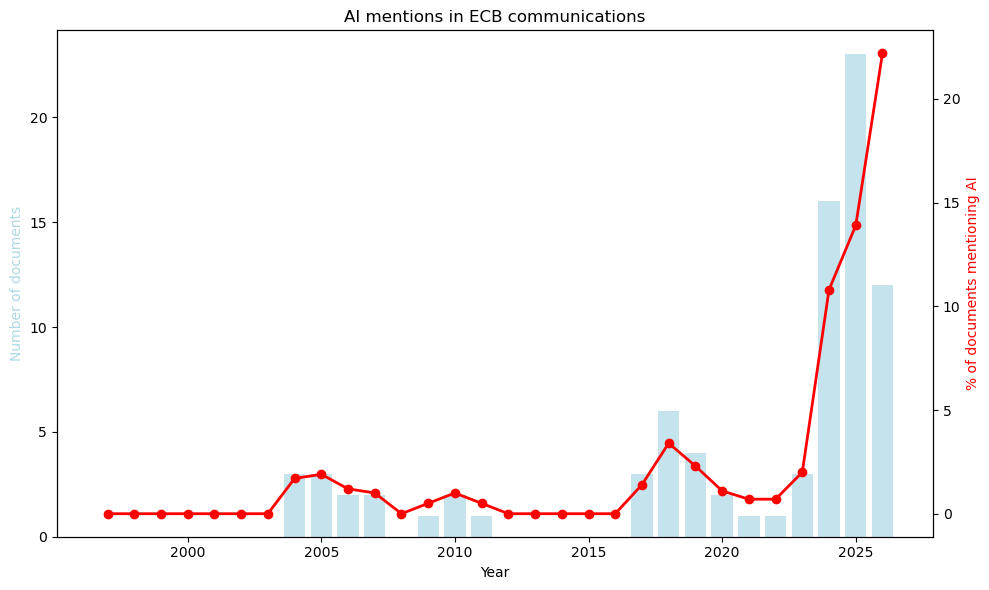

In [27]:
import matplotlib.pyplot as plt

ai_by_year = df.groupby("year").agg(
    total_articles=("title", "count"),
    ai_articles=("has_ai_mention", "sum"),
).reset_index()

ai_by_year["ai_percentage"] = (
    ai_by_year["ai_articles"] / ai_by_year["total_articles"] * 100
).round(1)

print("AI Mentions by Year:")
print(ai_by_year.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(ai_by_year["year"], ai_by_year["ai_articles"],
        color="lightblue", alpha=0.7, label="Documents mentioning AI")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of documents", color="lightblue")

ax2 = ax1.twinx()
ax2.plot(ai_by_year["year"], ai_by_year["ai_percentage"],
         color="red", marker="o", linewidth=2)
ax2.set_ylabel("% of documents mentioning AI", color="red")

plt.title("AI mentions in ECB communications")
fig.tight_layout()
plt.savefig("data/chart_ai_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 Mentions by Document Type

This chart compares which document type mentions which topic more often.

Mentions by document type:
     doc_type  total  ai  digital  monetary
press_release   2184   4       36      2025
       speech   2705  81      285      2305


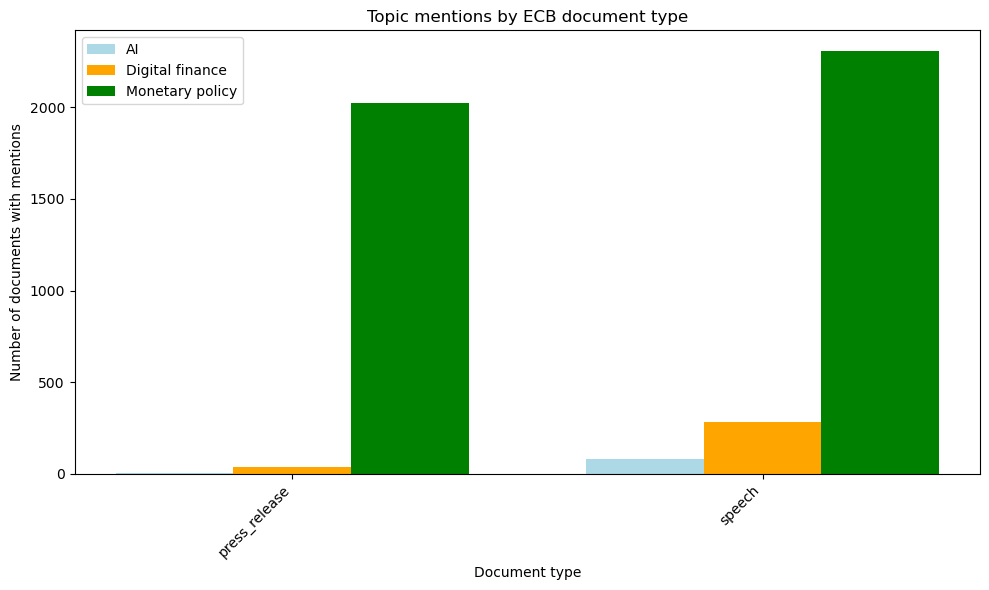

In [12]:
by_type = df.groupby("doc_type").agg(
    total=("title", "count"),
    ai=("has_ai_mention", "sum"),
    digital=("has_digital_mention", "sum"),
    monetary=("has_monetary_mention", "sum"),
).reset_index()

print("Mentions by document type:")
print(by_type.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(by_type))
width = 0.25

ax.bar([i - width for i in x], by_type["ai"],
       width, label="AI", color="lightblue")
ax.bar(x, by_type["digital"],
       width, label="Digital finance", color="orange")
ax.bar([i + width for i in x], by_type["monetary"],
       width, label="Monetary policy", color="green")

ax.set_xlabel("Document type")
ax.set_ylabel("Number of documents with mentions")
ax.set_title("Topic mentions by ECB document type")
ax.set_xticks(x)
ax.set_xticklabels(by_type["doc_type"], rotation=45, ha="right")
ax.legend()

fig.tight_layout()
plt.savefig("data/chart_by_doc_type.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 All topics over time

This chart shows how all three topics evolve over time. Monetary policy should be consistently high (it is the ECB's core topic), while AI and digital finance should grow over the years.

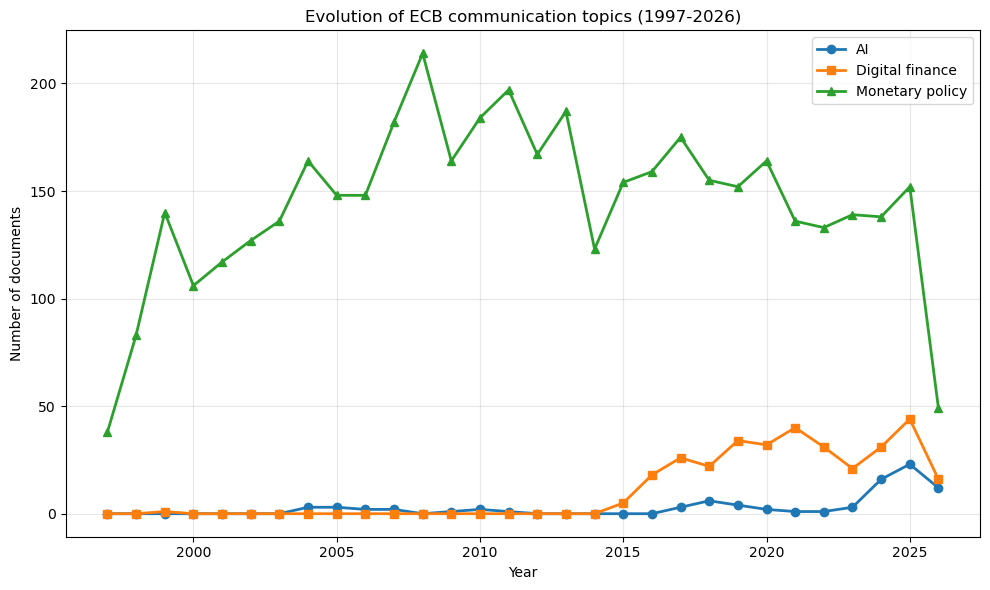

In [14]:
topics = df.groupby("year").agg(
    ai=("has_ai_mention", "sum"),
    digital=("has_digital_mention", "sum"),
    monetary=("has_monetary_mention", "sum"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(topics["year"], topics["ai"],
        marker="o", label="AI", linewidth=2)
ax.plot(topics["year"], topics["digital"],
        marker="s", label="Digital finance", linewidth=2)
ax.plot(topics["year"], topics["monetary"],
        marker="^", label="Monetary policy", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Number of documents")
ax.set_title("Evolution of ECB communication topics (1997-2026)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig("data/chart_topics_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Example AI mentioning documents

In [18]:
ai_docs = df[df["has_ai_mention"] == True].sort_values("date_normalised") 
print(f"Found {len(ai_docs)} documents mentioning AI topics\n")

print("First 15 AI-mentioning documents:")
for _, row in ai_docs.head(15).iterrows():
    print(f" [{row['date_normalised']}] [{row['doc_type']}] {str(row['title'])[:80]}")

    if pd.notna(row.get("link")) and row["link"]:
        print(f"    Link: {row['link']}")
    print(f" AI mentions in text: {row['ai_mention_count']}")
    print(f" Matched words: {', '.join(set(RE_AI.findall(row['search_text']))) if row['ai_mention_count'] > 0 else 'None'}")      

Found 85 documents mentioning AI topics

First 15 AI-mentioning documents:
 [2004-07-09] [speech] The current state of the European economy and the ECB's monetary policy concept
    Link: https://www.ecb.europa.eu/press/key/date/2004/html/sp040709.en.html
 AI mentions in text: 1
 Matched words: ai
 [2004-10-25] [speech] Presentation of the ECB's Annual Report 2003 to the European Parliament
    Link: https://www.ecb.europa.eu/press/key/date/2004/html/sp041025.en.html
 AI mentions in text: 1
 Matched words: ai
 [2004-11-30] [speech] Testimony before the Committee on Economic and Monetary Affairs of the European 
    Link: https://www.ecb.europa.eu/press/key/date/2004/html/sp041130.en.html
 AI mentions in text: 1
 Matched words: ai
 [2005-03-14] [speech] Testimony before the Committee on Economic and Monetary Affairs of the European 
    Link: https://www.ecb.europa.eu/press/key/date/2005/html/sp050314.en.html
 AI mentions in text: 1
 Matched words: ai
 [2005-07-04] [speech] Presentation

## 9. Final dataframe

In [16]:
# Saving the final dataset with all metadata and mention counts

final_columns = [
    "doc_type",
    "title",
    "date_normalised",
    "year",
    "link",
    "has_ai_mention",
    "ai_mention_count",
    "has_digital_mention",
    "digital_mention_count",
    "has_monetary_mention",
    "monetary_mention_count",
]

for col in ["subtitle", "full_text", "description"]:
    if col in df.columns:
        final_columns.append(col)

df_final = df[final_columns].copy()
df_final = df_final.sort_values("date_normalised").reset_index(drop=True)

FINAL_OUTPUT = "data/ecb_final_dataset.csv"
df_final.to_csv(FINAL_OUTPUT, index=False, encoding="utf-8")

print(f"Final dataset saved to {FINAL_OUTPUT}")
print(f"Shape: {df_final.shape}\n")
print(f"Total documents: {len(df_final)}")
print(f" Speeches: {len(df_final[df_final['doc_type']=='speech'])}")
print(f" Press releases: {len(df_final[df_final['doc_type']=='press_release'])}")
print(f"Date range: {df_final['date_normalised'].min()} to {df_final['date_normalised'].max()}")
print(f"AI mentions: {df_final['has_ai_mention'].sum()}")
print(f"Digital mentions: {df_final['has_digital_mention'].sum()}")
print(f"Monetary mentions: {df_final['has_monetary_mention'].sum()}")

Final dataset saved to data/ecb_final_dataset.csv
Shape: (4891, 13)

Total documents: 4891
 Speeches: 2705
 Press releases: 2184
Date range: 1997-02-07 to 2026-04-01
AI mentions: 85
Digital mentions: 321
Monetary mentions: 4331


In [64]:
df_final.head(20)

,doc_type,title,date_normalised,year,link,has_ai_mention,ai_mention_count,has_digital_mention,digital_mention_count,has_monetary_mention,monetary_mention_count,subtitle,full_text
0,speech,Fostering resilience and convergence in Econom...,2019-01-07,2019,https://www.ecb.europa.eu/press/key/date/2019/...,False,0,False,0,True,6,"Keynote speech by Luis de Guindos, Vice-Presid...",Fostering resilience and convergence in Econom...
1,speech,Tenth anniversary of the euro in Slovakia,2019-01-11,2019,https://www.ecb.europa.eu/press/key/date/2019/...,False,0,False,0,True,3,"Speech by Yves Mersch, Member of the Executive...",Tenth anniversary of the euro in Slovakia Spee...
2,speech,20th anniversary of the euro,2019-01-15,2019,https://www.ecb.europa.eu/press/key/date/2019/...,False,0,False,0,True,3,"Speech by Mario Draghi, President of the Europ...",20th anniversary of the euro Speech by Mario D...
3,speech,Debate about the Annual Report,2019-01-15,2019,https://www.ecb.europa.eu/press/key/date/2019/...,False,0,False,0,True,45,"Speech by Mario Draghi, President of the Europ...",Debate about the Annual Report Speech by Mario...
4,press_release,ECB publishes single Code of Conduct for high-...,2019-01-16,2019,https://www.ecb.europa.eu/press/pr/date/2019/h...,False,0,False,0,True,3,NaN,ANYTIME PAST MONTH PAST YEAR Search Options Im...
5,speech,A supervisory perspective on 2019 and beyond,2019-01-17,2019,https://www.ecb.europa.eu/press/key/date/2019/...,False,0,True,4,True,1,"Speech by Sabine Lautenschläger, Member of the...",Speech A supervisory perspective on 2019 and b...
6,press_release,Private sector working group publishes “Guidin...,2019-01-21,2019,https://www.ecb.europa.eu/press/pr/date/2019/h...,False,0,False,0,True,1,NaN,ANYTIME PAST MONTH PAST YEAR Search Options Im...
7,press_release,Results of the January 2019 euro area bank len...,2019-01-22,2019,https://www.ecb.europa.eu/press/pr/date/2019/h...,False,0,False,0,True,8,NaN,ANYTIME PAST MONTH PAST YEAR Search Options Im...
8,press_release,Euro banknote counterfeiting decreased further...,2019-01-25,2019,https://www.ecb.europa.eu/press/pr/date/2019/h...,False,0,False,0,True,1,NaN,ANYTIME PAST MONTH PAST YEAR Search Options Im...
9,press_release,Results of the Q1 2019 ECB Survey of Professio...,2019-01-25,2019,https://www.ecb.europa.eu/press/pr/date/2019/h...,False,0,False,0,True,5,NaN,ANYTIME PAST MONTH PAST YEAR Search Options Im...


## 10. Conclusion

This project scraped the ECB website to collect speeches and press releases from 1997 to 2026. Here is a summary of what was done:

1. **Data discovery** - I found that the ECB's website uses a JSON dataset internally, which contains metadata for all their publications. This was better than RSS feeds (which only have the 15 most recent items) and better than archive pages (which are inconsistent).

2. **Data collection** - I used `requests` to download speech and press release metadata from the JSON dataset. I also used `BeautifulSoup` to validate the JSON data against the actual HTML pages.

3. **Full text extraction** - I used `Selenium` for speeches and `Scrapy` for press releases, so each tool handles a different content type.

4. **Analysis** - I used Python `re` (regex) to search for AI, digital finance, and monetary policy keywords. The word boundary `\b` anchor was important to avoid false matches (like matching 'said' when looking for 'AI').

5. **Final output** - A structured dataframe with all documents, enriched with topic classification columns.

The most interesting finding is that AI mentions in ECB communications were relatively low and even declining between 2019 and 2023, but then increased sharply from 2024 onwards, reaching 25.9% of all documents in 2026 (compared to just 2% in 2022, although 2026 has not ended yet). This coincides with the rise of generative AI tools like ChatGPT and the EU AI Act entering the regulatory agenda.

All scraping was done politely, respecting the ECB's `robots.txt` crawl delay of 5 seconds, and the project is for non-commercial academic purposes.